In [2]:
import scanpy as sc
import tempfile
import requests
import os 


temp_combined_path = os.path.join(tempfile.gettempdir(), "adata_combined.h5ad")
adata= sc.read_h5ad(temp_combined_path)

temp_cereb_path = os.path.join(tempfile.gettempdir(), "cereb_combined.h5ad")
cereb_data = sc.read_h5ad(temp_cereb_path)

In [3]:
shared_genes = list(set(adata.var_names) & set(cereb_data.var_names))
adata_sub = adata[:, shared_genes]
cereb_sub = cereb_data[:, shared_genes]

cereb_sub

View of AnnData object with n_obs × n_vars = 82862 × 120
    obs: 'orig_cluster', 'orig_sub_cluster', 'broad_lineage', 'author_cell_type', 'dev_state', 'subtype', 'precisest_label', 'tissue_id', 'batch', 'size_factor', 'donor_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'is_primary_data', 'author_stage', 'tissue_fragment', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_counts', 'n_genes'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'batch_condition', 'cell_type_colors', 'citation', 'default_embedding', 'disease_colors', 'neighbors', 'organism', 'organism_ontology_term_id', 'pca', 'schema_reference', 'schema_ve

In [4]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

X_ad = adata_sub.X
y_ad = LabelEncoder().fit_transform(adata_sub.obs["disease"])  # e.g., AD vs Control

X_cereb = cereb_sub.X
if "development_stage" in cereb_sub.obs.columns:
    y_cereb = LabelEncoder().fit_transform(cereb_sub.obs["development_stage"])
else:
    y_cereb = np.zeros(X_cereb.shape[0])

print(X_ad)

#print(y_ad)

[[ 1.8667912   4.334699    1.6808316  ... -0.30498332  1.9206043
  -0.23413831]
 [-0.7609318   4.91383    -0.7342432  ... -0.30498332  1.9517746
  -0.23413831]
 [-0.7609318  -0.2863129   2.2742157  ... -0.30498332  2.2310138
  -0.23413831]
 ...
 [ 1.4262611  -0.2863129  -0.7342432  ... -0.30498332 -0.65869987
  -0.23413831]
 [ 0.7378019  -0.2863129   0.7973264  ... -0.30498332 -0.65869987
  -0.23413831]
 [ 1.3361171  -0.2863129   0.1351617  ...  1.1559224  -0.65869987
  -0.23413831]]


In [5]:
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel

# SVM for AD
svm_ad = LinearSVC(C=0.01, penalty='l1', dual=False, max_iter=5000)
svm_ad.fit(X_ad, y_ad)
selected_ad = np.abs(svm_ad.coef_).sum(axis=0)

# SVM for Cerebellum
svm_cereb = LinearSVC(C=0.01, penalty='l1', dual=False, max_iter=5000)
svm_cereb.fit(X_cereb, y_cereb)
selected_cereb = np.abs(svm_cereb.coef_).sum(axis=0)

# Top genes
top_n = 50
genes_array = np.array(shared_genes)
top_ad_genes = genes_array[np.argsort(selected_ad)[-top_n:]]
top_cereb_genes = genes_array[np.argsort(selected_cereb)[-top_n:]]
overlap = set(top_ad_genes) & set(top_cereb_genes)
print(f"Overlap ({len(overlap)}): {overlap}")


Overlap (23): {'ENSG00000210082', 'ENSG00000170624', 'ENSG00000183878', 'ENSG00000165246', 'ENSG00000211459', 'ENSG00000245532', 'ENSG00000280441', 'ENSG00000115252', 'ENSG00000147408', 'ENSG00000204389', 'ENSG00000109906', 'ENSG00000114757', 'ENSG00000120694', 'ENSG00000152583', 'ENSG00000269821', 'ENSG00000198727', 'ENSG00000176728', 'ENSG00000227110', 'ENSG00000198804', 'ENSG00000198840', 'ENSG00000123560', 'ENSG00000118785', 'ENSG00000189056'}


In [6]:
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split


# Split the AD data
X_ad_train, X_ad_test, y_ad_train, y_ad_test = train_test_split(
    X_ad, y_ad, test_size=0.2, random_state=42
)

# Split the Cerebellum data
X_cereb_train, X_cereb_test, y_cereb_train, y_cereb_test = train_test_split(
    X_cereb, y_cereb, test_size=0.2, random_state=42
)

# Train MLP for AD classification
mlp_ad = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=200,
    early_stopping=True,
    random_state=42,
    verbose=True
)
mlp_ad.fit(X_ad_train, y_ad_train)

# Evaluate AD model
print("AD Classification Report:")
y_ad_pred = mlp_ad.predict(X_ad_test)
print(classification_report(y_ad_test, y_ad_pred))
print("AD Accuracy:", accuracy_score(y_ad_test, y_ad_pred))

Iteration 1, loss = 0.31431190
Validation score: 0.978656
Iteration 2, loss = 0.04247062
Validation score: 0.987352
Iteration 3, loss = 0.02453205
Validation score: 0.989723
Iteration 4, loss = 0.01592016
Validation score: 0.989723
Iteration 5, loss = 0.01083331
Validation score: 0.988142
Iteration 6, loss = 0.00782410
Validation score: 0.988933
Iteration 7, loss = 0.00561375
Validation score: 0.988933
Iteration 8, loss = 0.00403803
Validation score: 0.988933
Iteration 9, loss = 0.00290296
Validation score: 0.987352
Iteration 10, loss = 0.00229274
Validation score: 0.987352
Iteration 11, loss = 0.00170688
Validation score: 0.987352
Iteration 12, loss = 0.00136225
Validation score: 0.987352
Iteration 13, loss = 0.00110673
Validation score: 0.987352
Iteration 14, loss = 0.00093694
Validation score: 0.987352
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
AD Classification Report:
              precision    recall  f1-score   support

         

In [7]:
# Train MLP for Cerebellum classification
mlp_cereb = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=200,
    early_stopping=True,
    random_state=42,
    verbose=True
)
mlp_cereb.fit(X_cereb_train, y_cereb_train)

# Evaluate Cerebellum model
print("Cerebellum Classification Report:")
y_cereb_pred = mlp_cereb.predict(X_cereb_test)
print()
print(classification_report(y_cereb_test, y_cereb_pred))
print()
print("Cerebellum Accuracy:", accuracy_score(y_cereb_test, y_cereb_pred))

Iteration 1, loss = 1.55440315
Validation score: 0.746266
Iteration 2, loss = 0.63170066
Validation score: 0.800422
Iteration 3, loss = 0.50450035
Validation score: 0.808870
Iteration 4, loss = 0.43353067
Validation score: 0.836476
Iteration 5, loss = 0.38771397
Validation score: 0.845075
Iteration 6, loss = 0.35394082
Validation score: 0.842812
Iteration 7, loss = 0.32585659
Validation score: 0.852014
Iteration 8, loss = 0.30006979
Validation score: 0.859255
Iteration 9, loss = 0.27640650
Validation score: 0.857746
Iteration 10, loss = 0.26271748
Validation score: 0.866345
Iteration 11, loss = 0.24942821
Validation score: 0.866797
Iteration 12, loss = 0.23495599
Validation score: 0.855634
Iteration 13, loss = 0.22088225
Validation score: 0.864384
Iteration 14, loss = 0.20654442
Validation score: 0.864535
Iteration 15, loss = 0.20036003
Validation score: 0.870267
Iteration 16, loss = 0.18661714
Validation score: 0.866043
Iteration 17, loss = 0.18533617
Validation score: 0.863026
Iterat

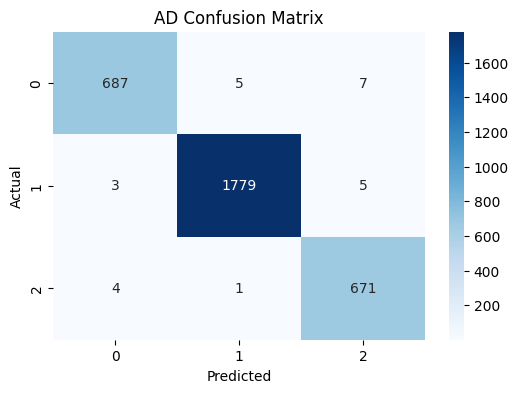

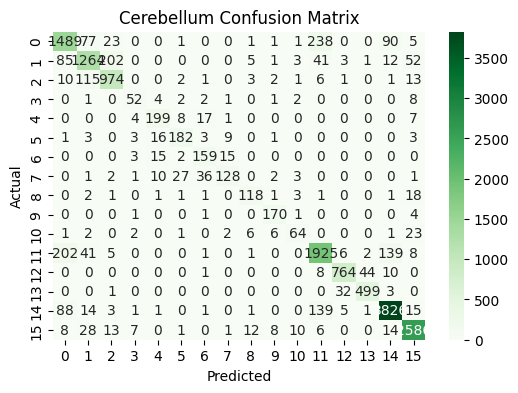

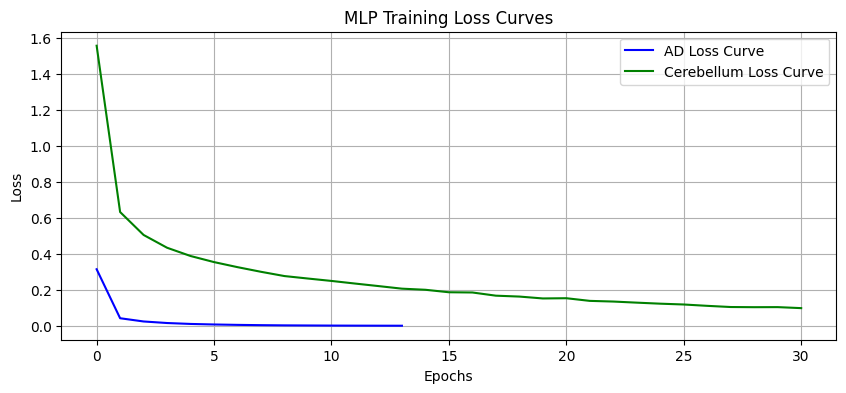

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

ad_conf_matrix = confusion_matrix(y_ad_test, y_ad_pred)
cereb_conf_matrix = confusion_matrix(y_cereb_test, y_cereb_pred)

#AD confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(ad_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("AD Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#Cerebellum confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cereb_conf_matrix, annot=True, fmt='d', cmap='Greens')
plt.title("Cerebellum Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#learning curves
ad_loss_curve = mlp_ad.loss_curve_ if hasattr(mlp_ad, "loss_curve_") else []
cereb_loss_curve = mlp_cereb.loss_curve_ if hasattr(mlp_cereb, "loss_curve_") else []

plt.figure(figsize=(10, 4))
plt.plot(ad_loss_curve, label='AD Loss Curve', color='blue')
plt.plot(cereb_loss_curve, label='Cerebellum Loss Curve', color='green')
plt.title("MLP Training Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
import tensorflow.keras as keras

2025-08-02 08:02:47.716699: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-02 08:02:49.246308: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754136169.677746 1684020 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754136169.791040 1684020 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754136171.183462 1684020 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [10]:
#Defining the loss function  and optimizer
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

optim = keras.optimizers.Adam(learning_rate=0.001)


2025-08-02 08:02:59.689575: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


AD Neural network

In [11]:
# Neural netwwork with keras --> next move 


#Creating the NN Architecture  with ad data


nn_model = keras.Sequential()

#Input layer 
input_layer = keras.layers.InputLayer(input_shape = ((X_ad_train.shape[1]),))
nn_model.add(input_layer)

#Hidden layer 1
hidden_layer_1 = keras.layers.Dense(units = 128, activation="relu")
nn_model.add(hidden_layer_1)

#Hidden layer 2
hidden_layer_2 = keras.layers.Dense(units=64, activation="relu")
nn_model.add(hidden_layer_2)

#hidden layer 3
hidden_layer_3 = keras.layers.Dense(units=32, activation="relu")
nn_model.add(hidden_layer_3)
dropout = keras.layers.Dropout(0.2)
nn_model.add(dropout)

#extra hidden layer 
hidden_layer_5 = keras.layers.Dense(units=16, activation="relu")
nn_model.add(hidden_layer_5)
nn_model.add(keras.layers.Dropout(0.2))

#hidden layer 4 / output 5
hidden_layer_4 = keras.layers.Dense(units=1, activation="sigmoid")
nn_model.add(hidden_layer_4)


 #Compiling the model
nn_model.compile(optimizer=optim, loss=loss_fn, metrics=["accuracy"])


#Summary 
nn_model.summary()


/users/imbahndu/.local/lib/python3.9/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        15,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,369 (103.00 KB)

 Trainable params: 26,369 (103.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
print(X_ad_train.shape)

(12645, 120)


In [13]:
#Fitting the model
num_epochs = 50
model = nn_model.fit(X_ad_train, y_ad_train,
 epochs=num_epochs, validation_split=0.3)

Epoch 1/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5965 - loss: -1335.6166 - val_accuracy: 0.6099 - val_loss: -82297.8984
Epoch 2/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6170 - loss: -454023.6875 - val_accuracy: 0.5538 - val_loss: -4434777.0000
Epoch 3/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6032 - loss: -8371731.5000 - val_accuracy: 0.5538 - val_loss: -35527952.0000
Epoch 4/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5937 - loss: -53423264.0000 - val_accuracy: 0.5538 - val_loss: -147404224.0000
Epoch 5/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6059 - loss: -187850112.0000 - val_accuracy: 0.5538 - val_loss: -428542112.0000
Epoch 6/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5746 - loss: -518185472.0000 - val_accuracy: 0.5538 - val_loss: -1000686144.0000
Epoch 7/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5729 - loss: -1112505216.0000 - val_accuracy: 0.5538 - val_loss: -200175833

277/277 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5721 - loss: -36856598528.0000 - val_accuracy: 0.5538 - val_loss: -49805840384.0000
Epoch 16/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5684 - loss: -51187720192.0000 - val_accuracy: 0.5538 - val_loss: -64581341184.0000
Epoch 17/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5700 - loss: -66560548864.0000 - val_accuracy: 0.5538 - val_loss: -81830854656.0000
Epoch 18/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5676 - loss: -82712100864.0000 - val_accuracy: 0.5538 - val_loss: -102306856960.0000
Epoch 19/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5710 - loss: -103759675392.0000 - val_accuracy: 0.5538 - val_loss: -126333542400.0000
Epoch 20/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5742 - loss: -127159009280.0000 - val_accuracy: 0.5538 - val_loss: -154410827776.0000
Epoch 21/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5782 - loss: -156502441984.0000 - 

Accuracy decreasing instead of increasin and loss is negative, damn

Cereb NN

In [14]:
print(X_cereb_train.shape)

(66289, 120)


In [15]:
# Neural netwwork with keras --> next move 


#Creating the NN Architecture  with ad data


nn_model = keras.Sequential()

#Input layer 
input_layer = keras.layers.InputLayer(input_shape = ((X_cereb_train.shape[1]),))
nn_model.add(input_layer)

#Hidden layer 1
hidden_layer_1 = keras.layers.Dense(units = 128, activation="relu")
nn_model.add(hidden_layer_1)

#Hidden layer 2
hidden_layer_2 = keras.layers.Dense(units=64, activation="relu")
nn_model.add(hidden_layer_2)

#hidden layer 3
hidden_layer_3 = keras.layers.Dense(units=32, activation="relu")
nn_model.add(hidden_layer_3)
dropout = keras.layers.Dropout(0.2)
nn_model.add(dropout)

#extra hidden layer 
hidden_layer_5 = keras.layers.Dense(units=16, activation="relu")
nn_model.add(hidden_layer_5)
nn_model.add(keras.layers.Dropout(0.2))

#hidden layer 4 / output 5
hidden_layer_4 = keras.layers.Dense(units=1, activation="sigmoid")
nn_model.add(hidden_layer_4)


 #Compiling the model
nn_model.compile(optimizer=optim, loss=loss_fn, metrics=["accuracy"])


#Summary 
nn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │        15,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,109 (309.02 KB)

 Trainable params: 26,369 (103.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 52,740 (206.02 KB)

In [16]:
import tensorflow as tf
tf.compat.v1.enable_eager_execution()
# If X_cereb_train is a SparseCSRView from AnnDat
X_cereb_train_dense = np.array(X_cereb_train.A)  # safer than .toarray()
y_cereb_train = np.array(y_cereb_train)  

#Fitting the model
num_epochs = 50
model = nn_model.fit(X_cereb_train_dense, y_cereb_train,
 epochs=num_epochs, validation_split=0.3)

Epoch 1/50


NotImplementedError: numpy() is only available when eager execution is enabled.

In [17]:
from sklearn.inspection import permutation_importance

# Convert to dense if needed
X_ad_test_array = X_ad_test.toarray() if hasattr(X_ad_test, "toarray") else X_ad_test
X_cereb_test_array = X_cereb_test.toarray() if hasattr(X_cereb_test, "toarray") else X_cereb_test

# Permutation importance on test sets only
perm_ad = permutation_importance(mlp_ad, X_ad_test_array, y_ad_test, n_repeats=10, random_state=42)
top_nn_ad = genes_array[np.argsort(perm_ad.importances_mean)[-top_n:]]

perm_cereb = permutation_importance(mlp_cereb, X_cereb_test_array, y_cereb_test, n_repeats=10, random_state=42)
top_nn_cereb = genes_array[np.argsort(perm_cereb.importances_mean)[-top_n:]]

# Overlapping genes in NN-based importance
overlap_nn = set(top_nn_ad) & set(top_nn_cereb)
print(f"Overlap in NN-important genes: {overlap_nn}")


Overlap in NN-important genes: {'ENSG00000210082', 'ENSG00000170624', 'ENSG00000183878', 'ENSG00000185565', 'ENSG00000052126', 'ENSG00000185532', 'ENSG00000211459', 'ENSG00000165246', 'ENSG00000151474', 'ENSG00000174469', 'ENSG00000280441', 'ENSG00000115252', 'ENSG00000067798', 'ENSG00000198899', 'ENSG00000204389', 'ENSG00000120694', 'ENSG00000135298', 'ENSG00000189337', 'ENSG00000140945', 'ENSG00000198727', 'ENSG00000176728', 'ENSG00000175161', 'ENSG00000185736', 'ENSG00000185737', 'ENSG00000198804', 'ENSG00000198840', 'ENSG00000176204'}


Doing what Majoie suggested, training on one dataset and testing on the data

In [18]:

# Convert sparse to dense if needed
X_ad_dense = X_ad.A if hasattr(X_ad, "A") else X_ad
X_cereb_dense = X_cereb.A if hasattr(X_cereb, "A") else X_cereb

# Train MLP on AD data
mlp_ad = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=200,
    early_stopping=True,
    random_state=42,
    verbose=True
)
mlp_ad.fit(X_ad_dense, y_ad)

# Predict on Cerebellum data
y_cereb_pred = mlp_ad.predict(X_cereb_dense)

Iteration 1, loss = 0.27181744
Validation score: 0.990512
Iteration 2, loss = 0.03611664
Validation score: 0.991777
Iteration 3, loss = 0.02147664
Validation score: 0.991777
Iteration 4, loss = 0.01445752
Validation score: 0.992410
Iteration 5, loss = 0.01005345
Validation score: 0.991777
Iteration 6, loss = 0.00683130
Validation score: 0.992410
Iteration 7, loss = 0.00483086
Validation score: 0.991777
Iteration 8, loss = 0.00358092
Validation score: 0.991777
Iteration 9, loss = 0.00269932
Validation score: 0.991777
Iteration 10, loss = 0.00186787
Validation score: 0.992410
Iteration 11, loss = 0.00139508
Validation score: 0.992410
Iteration 12, loss = 0.00110022
Validation score: 0.992410
Iteration 13, loss = 0.00088751
Validation score: 0.992410
Iteration 14, loss = 0.00072752
Validation score: 0.991777
Iteration 15, loss = 0.00061019
Validation score: 0.991777
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.


In [ ]:
# Evaluate
print("Crebellum Prediction Report (trained on AD):")
print(classification_report(y_cereb, y_cereb_pred))
print("Accuracy:", accuracy_score(y_cereb, y_cereb_pred))

\erebellum Prediction Report (trained on AD):
              precision    recall  f1-score   support

           0       0.06      0.02      0.04      9695
           1       0.10      0.93      0.18      8416
           2       0.09      0.01      0.01      5506
           3       0.00      0.00      0.00       380
           4       0.00      0.00      0.00      1019
           5       0.00      0.00      0.00      1106
           6       0.00      0.00      0.00       960
           7       0.00      0.00      0.00      1000
           8       0.00      0.00      0.00       768
           9       0.00      0.00      0.00       711
          10       0.00      0.00      0.00       532
          11       0.00      0.00      0.00     11348
          12       0.00      0.00      0.00      4179
          13       0.00      0.00      0.00      2828
          14       0.00      0.00      0.00     21024
          15       0.00      0.00      0.00     13390

    accuracy                      

/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Train on Cerebrum, Predict on AD

In [21]:

# Convert sparse to dense if needed
X_cereb_dense = X_cereb.A if hasattr(X_cereb, "A") else X_cereb
X_ad_dense = X_ad.A if hasattr(X_ad, "A") else X_ad

# Train MLP on Cerebellum data
mlp_cereb = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=200,
    early_stopping=True,
    random_state=42,
    verbose=True
)
mlp_cereb.fit(X_cereb_dense, y_cereb)

# Predict on AD data
y_ad_pred = mlp_cereb.predict(X_ad_dense)

Iteration 1, loss = 1.36762845
Validation score: 0.764812
Iteration 2, loss = 0.57875093
Validation score: 0.815253
Iteration 3, loss = 0.46722159
Validation score: 0.833233
Iteration 4, loss = 0.40525617
Validation score: 0.848920
Iteration 5, loss = 0.36540808
Validation score: 0.853264
Iteration 6, loss = 0.33431096
Validation score: 0.859177
Iteration 7, loss = 0.31021240
Validation score: 0.858453
Iteration 8, loss = 0.28679979
Validation score: 0.866659
Iteration 9, loss = 0.27078105
Validation score: 0.870279
Iteration 10, loss = 0.25340398
Validation score: 0.872934
Iteration 11, loss = 0.24365233
Validation score: 0.873899
Iteration 12, loss = 0.22991924
Validation score: 0.870158
Iteration 13, loss = 0.21793627
Validation score: 0.873175
Iteration 14, loss = 0.20778053
Validation score: 0.870279
Iteration 15, loss = 0.19938918
Validation score: 0.876916
Iteration 16, loss = 0.19308452
Validation score: 0.876916
Iteration 17, loss = 0.18268900
Validation score: 0.875226
Iterat

In [22]:
# Evaluate
print("Prediction Report (trained on Cerebellum")
print(classification_report(y_ad, y_ad_pred))
print("Accuracy:", accuracy_score(y_ad, y_ad_pred))

Prediction Report (trained on Cerebellum
              precision    recall  f1-score   support

           0       0.08      0.00      0.01      3635
           1       0.74      0.03      0.05      8939
           2       0.05      0.00      0.01      3233
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         0
          11       0.00      0.00      0.00         0
          12       0.00      0.00      0.00         0
          13       0.00      0.00      0.00         0
          14       0.00      0.00      0.00         0
          15       0.00      0.00      0.00         0

    accuracy                           0.02     15807
   macro avg       0.06      0.00      

/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/users/imbahndu/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/users/imbahndu/.local/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


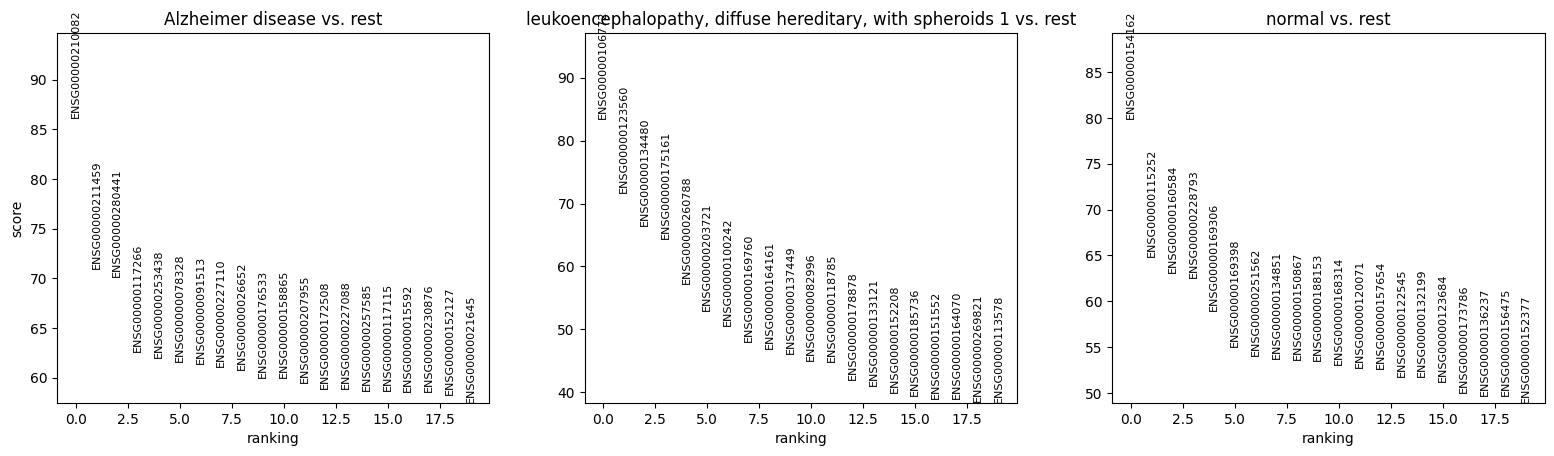

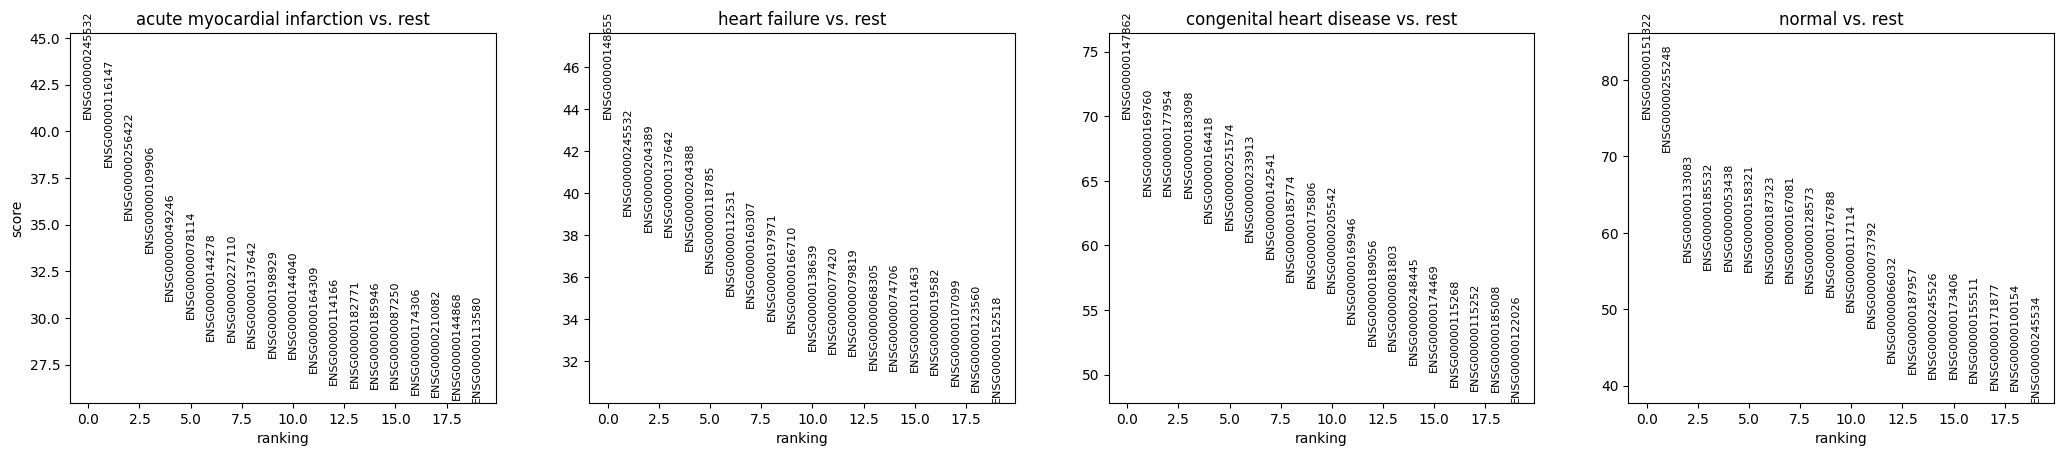

In [27]:
import scanpy as sc

# Assuming adata_ad and adata_cereb are AnnData objects
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.tl.rank_genes_groups(adata, groupby='disease', method='wilcoxon')

sc.pp.normalize_total(cereb_data, target_sum=1e4)
sc.pp.log1p(cereb_data)
sc.tl.rank_genes_groups(cereb_data, groupby='disease', method='wilcoxon')

# View top genes
sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)
sc.pl.rank_genes_groups(cereb_data, n_genes=20, sharey=False)